## Импорты библиотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, learning_curve
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
import shap
import warnings
warnings.filterwarnings('ignore')
import optuna

## Загрузка данных

In [ ]:
train = pd.read_csv('../data/processed/train_final.csv')
test  = pd.read_csv('../data/processed/test_final.csv')

"\ntrain = pd.read_csv('../data/processed/train_final.csv')\ntest  = pd.read_csv('../data/processed/test_final.csv')\n"

In [ ]:
train.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_unbrch_alkane,fr_urea,Feature_Density_Wt,Feature_LogP_Surface,Feature_Arom_Ratio,Feature_Valence_per_Atom,Feature_Complexity,"sqrt_IC50, mM","sqrt_CC50, mM",sqrt_SI
0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,195.287,...,0,0,15.022065,0.026199,0.499998,5.384611,504.292077,10.120001,9.785575,0.966954
1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,360.907,...,0,0,15.691602,0.020841,0.499998,5.652171,1489.722453,0.210554,2.898462,13.765900
2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,315.457,...,0,0,13.715516,0.027420,0.249999,5.478258,875.271184,2.106647,7.077117,3.359422
3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,439.375,...,0,0,14.645828,0.028896,0.999997,5.199998,2468.386395,2.613021,26.130213,10.000000
4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,151.253,...,0,0,13.750260,0.028003,0.000000,5.636359,291.054049,1.415363,8.366687,5.911336


In [ ]:
SEED = 42
N_SPLITS = 5
TARGETS = ['sqrt_IC50, mM', 'sqrt_CC50, mM', 'sqrt_SI']
TARGETS_ORIG = ['IC50, mM', 'CC50, mM', 'SI']

def custom_rmse(y_true_ic, y_true_cc, y_true_si, y_pred_ic, y_pred_cc, y_pred_si):
    rmse_ic = np.sqrt(np.mean((y_true_ic - y_pred_ic)**2))
    rmse_cc = np.sqrt(np.mean((y_true_cc - y_pred_cc)**2))
    rmse_si = np.sqrt(np.mean((y_true_si - y_pred_si)**2))
    return (rmse_ic + rmse_cc + rmse_si) / 3.0

In [ ]:
exclude = TARGETS + TARGETS_ORIG + ['index']
feature_cols = [c for c in train.columns if c not in exclude]

X = train[feature_cols].values
y = train[TARGETS].values
y_orig = train[TARGETS_ORIG].values
X_test = test[feature_cols].values

print(f"Train: {X.shape}, Test: {X_test.shape}")
print(f"Таргеты (sqrt): {TARGETS}")

Train: (729, 197), Test: (250, 197)
Таргеты (sqrt): ['sqrt_IC50, mM', 'sqrt_CC50, mM', 'sqrt_SI']


## Параметры моделей

In [ ]:
models_config = {
    'RandomForest': (RandomForestRegressor, {
        'n_estimators': 300, 'max_depth': 10, 'n_jobs': -1
    }),
    'CatBoost': (CatBoostRegressor, {
        'iterations': 500, 'depth': 6, 'learning_rate': 0.05, 'verbose': 0
    }),
    'LightGBM': (LGBMRegressor, {
        'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'verbose': -1
    }),
    'XGBoost': (XGBRegressor, {
        'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'verbosity': 0
    }),
}

## Предсказание

In [ ]:
def train_cv_direct(X, y, X_test, model_class, params):
    """
    Прямое предсказание всех трёх таргетов (IC50, CC50, SI).
    SI предсказывается моделью, а не вычисляется по формуле.
    Кросс-валидация 5 фолдов.
    """
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    preds_oof = np.zeros_like(y)
    preds_test = np.zeros((len(X_test), 3))

    for train_idx, val_idx in kf.split(X):
        fold_val = np.zeros((len(val_idx), 3))
        fold_test = np.zeros((len(X_test), 3))

        for target_idx in range(3):
            model = model_class(**params, random_state=SEED)
            model.fit(X[train_idx], y[train_idx, target_idx])
            fold_val[:, target_idx] = model.predict(X[val_idx])
            fold_test[:, target_idx] = model.predict(X_test)

        preds_oof[val_idx] = fold_val
        preds_test += fold_test / N_SPLITS

    preds_oof[:, 2] = np.clip(preds_oof[:, 2], 0, 4000)
    preds_test[:, 2] = np.clip(preds_test[:, 2], 0, 4000)

    return preds_oof, preds_test

## Прогон всех моделей

In [ ]:
train_cv = train_cv_direct

results = {}
for name, (model_class, params) in models_config.items():
    preds_oof, preds_test = train_cv(X, y, X_test, model_class, params)
    rmse = custom_rmse(
        y_orig[:, 0], y_orig[:, 1], y_orig[:, 2],
        np.clip(preds_oof[:, 0], 0, None)**2,
        np.clip(preds_oof[:, 1], 0, None)**2,
        np.clip(preds_oof[:, 2], 0, None)**2
    )
    results[name] = {'preds_oof': preds_oof, 'preds_test': preds_test, 'rmse': rmse}
    print(f"{name:<15} RMSE: {rmse:.4f}")

best_model = min(results, key=lambda x: results[x]['rmse'])
print(f"\nЛучшая модель: {best_model} (RMSE: {results[best_model]['rmse']:.4f})")

RandomForest    RMSE: 313.6768
CatBoost        RMSE: 310.3515
LightGBM        RMSE: 315.8347
XGBoost         RMSE: 321.6943

Лучшая модель: CatBoost (RMSE: 310.3515)


## Сравнение RMSE всех моделей (barh)

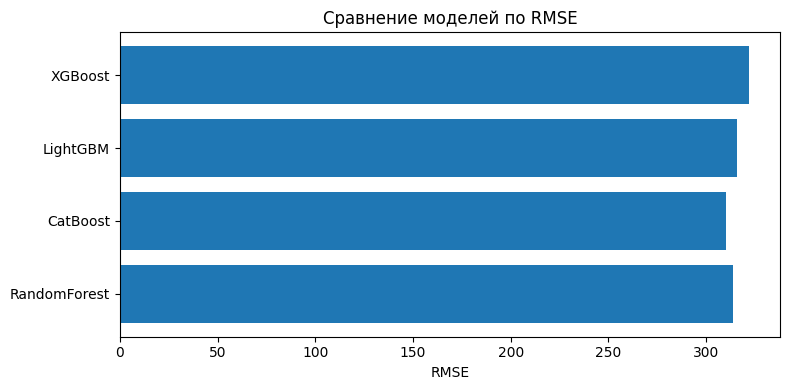

In [ ]:
rmse_values = {name: results[name]['rmse'] for name in results}
plt.figure(figsize=(8, 4))
plt.barh(list(rmse_values.keys()), list(rmse_values.values()))
plt.xlabel('RMSE')
plt.title('Сравнение моделей по RMSE')
plt.tight_layout()
plt.show()

Для исходного датасета, где все три таргета (sqrt_IC50, mM, sqrt_CC50, mM, sqrt_SI) предсказывались напрямую, наилучшее качество вновь показала модель CatBoost с RMSE = 310.35. Остальные ансамблевые модели продемонстрировали более высокую ошибку: RandomForest — 313.68, LightGBM — 315.83, XGBoost — 321.69.

Результаты подтверждают устойчивое преимущество CatBoost при работе с хемоинформатическими дескрипторами и сложными нелинейными зависимостями между признаками и биологической активностью. При этом прямое предсказание SI не ухудшило качество модели, что указывает на способность алгоритма самостоятельно выявлять скрытые взаимосвязи между токсичностью, активностью и селективностью соединений.

## Важность признаков — для каждой модели, все 3 цели

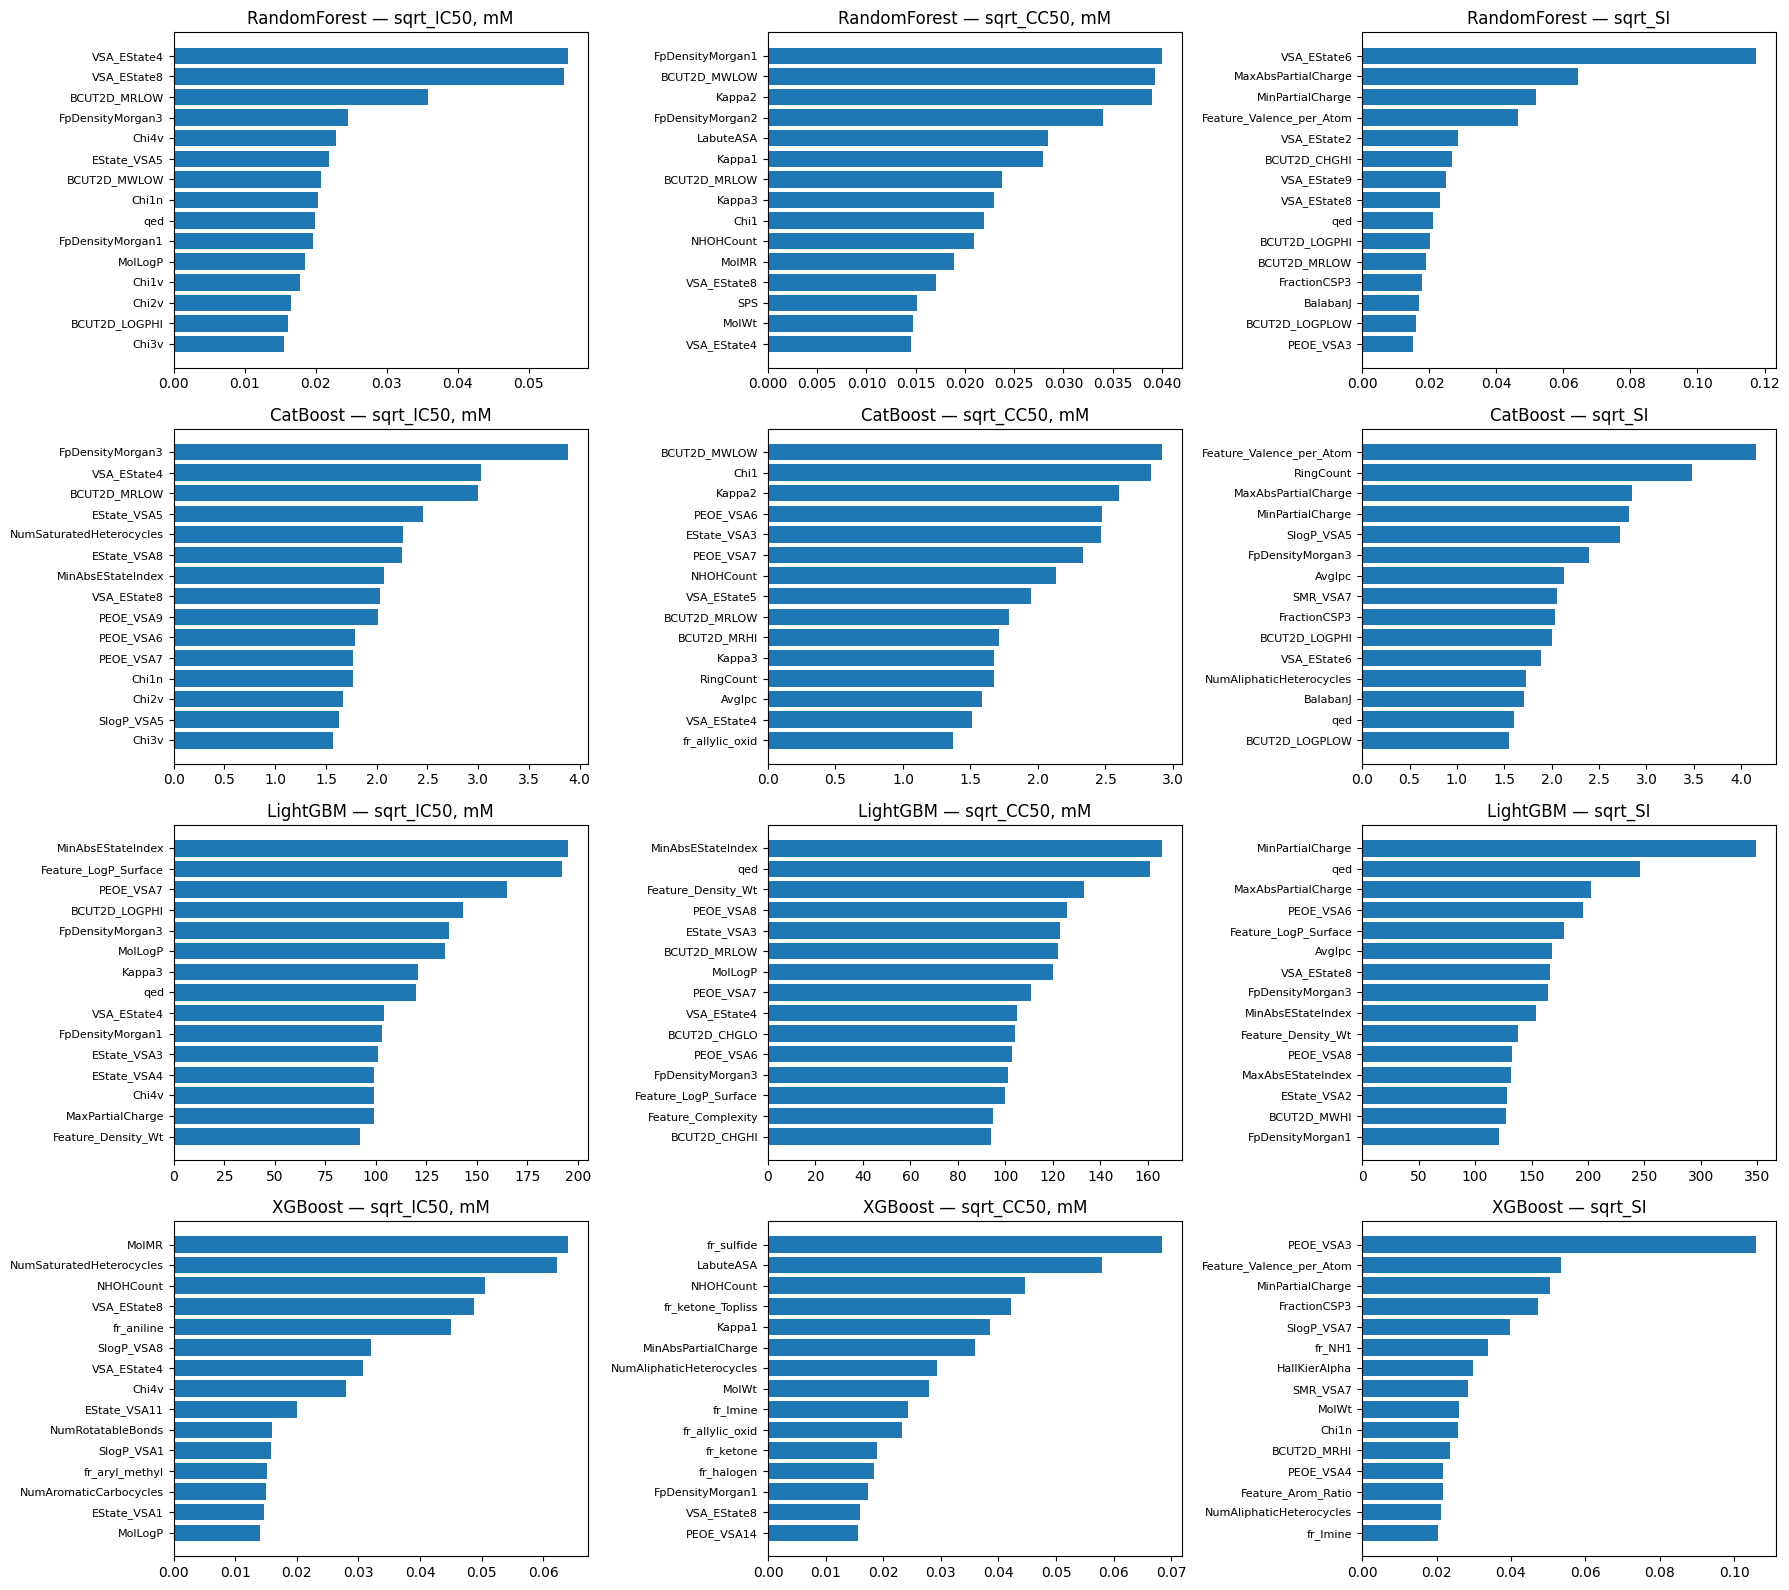

In [ ]:
fig, axes = plt.subplots(len(models_config), 3, figsize=(18, 4 * len(models_config)))

for row, (name, (model_class, params)) in enumerate(models_config.items()):
    for col, target_name in enumerate(TARGETS):
        model = model_class(**params, random_state=SEED)
        model.fit(X, y[:, col])

        if hasattr(model, 'feature_importances_'):
            imp = model.feature_importances_
            top_idx = np.argsort(imp)[-15:]
            axes[row, col].barh(range(15), imp[top_idx])
            axes[row, col].set_yticks(range(15))
            axes[row, col].set_yticklabels([feature_cols[i] for i in top_idx], fontsize=8)
            axes[row, col].set_title(f'{name} — {target_name}')
        else:
            axes[row, col].text(0.5, 0.5, 'Нет importance', ha='center', va='center')

plt.tight_layout()
plt.show()

## Сравнение топ-признаков между CatBoost, LightGBM, XGBoost для каждой цели

In [ ]:
boost_names = ['CatBoost', 'LightGBM', 'XGBoost']

for target_idx, target_name in enumerate(TARGETS):
    top_sets = {}
    for name in boost_names:
        model_class, params = models_config[name]
        model = model_class(**params, random_state=SEED)
        model.fit(X, y[:, target_idx])
        imp = model.feature_importances_
        top10 = set(np.array(feature_cols)[np.argsort(imp)[-10:]])
        top_sets[name] = top10

    common = top_sets[boost_names[0]] & top_sets[boost_names[1]] & top_sets[boost_names[2]]
    pairwise = {}
    for i, n1 in enumerate(boost_names):
        for n2 in boost_names[i+1:]:
            pairwise[f'{n1} & {n2}'] = len(top_sets[n1] & top_sets[n2])

    print(f"\n{target_name}:")
    print(f"  Общих для всех трёх: {len(common)} — {sorted(common)}")
    for pair, count in pairwise.items():
        print(f"  Общих {pair}: {count}/10")


sqrt_IC50, mM:
  Общих для всех трёх: 1 — [np.str_('VSA_EState4')]
  Общих CatBoost & LightGBM: 3/10
  Общих CatBoost & XGBoost: 3/10
  Общих LightGBM & XGBoost: 1/10

sqrt_CC50, mM:
  Общих для всех трёх: 0 — []
  Общих CatBoost & LightGBM: 3/10
  Общих CatBoost & XGBoost: 1/10
  Общих LightGBM & XGBoost: 0/10

sqrt_SI:
  Общих для всех трёх: 1 — [np.str_('MinPartialCharge')]
  Общих CatBoost & LightGBM: 4/10
  Общих CatBoost & XGBoost: 4/10
  Общих LightGBM & XGBoost: 1/10


Анализ важности признаков для исходного датасета с прямым предсказанием sqrt_SI показал, что модели сохраняют схожие закономерности и выделяют преимущественно дескрипторы электронного распределения, топологии и поверхностных свойств молекул.

Для sqrt_IC50 наиболее значимыми оказались признаки классов VSA_EState, BCUT2D_MRLOW, FpDensityMorgan3, а также топологические индексы Chi. Это указывает на важность электронной структуры и пространственной организации молекулы для противовирусной активности.

Для sqrt_CC50 модели чаще выделяли дескрипторы молекулярной сложности и размеров (BCUT2D_MWLOW, Kappa, MolWt, LabuteASA), что отражает связь токсичности с размером и структурной сложностью соединений.

При прямом прогнозировании sqrt_SI ключевыми стали признаки, связанные с зарядовым распределением и ароматичностью: MinPartialCharge, MaxAbsPartialCharge, Feature_Valence_per_Atom, SlogP_VSA7, FractionCSP3, SMR_VSA7. Это подтверждает, что селективность определяется более сложной комбинацией электронных и пространственных характеристик молекулы.

## Графики Actual vs Predicted для всех моделей

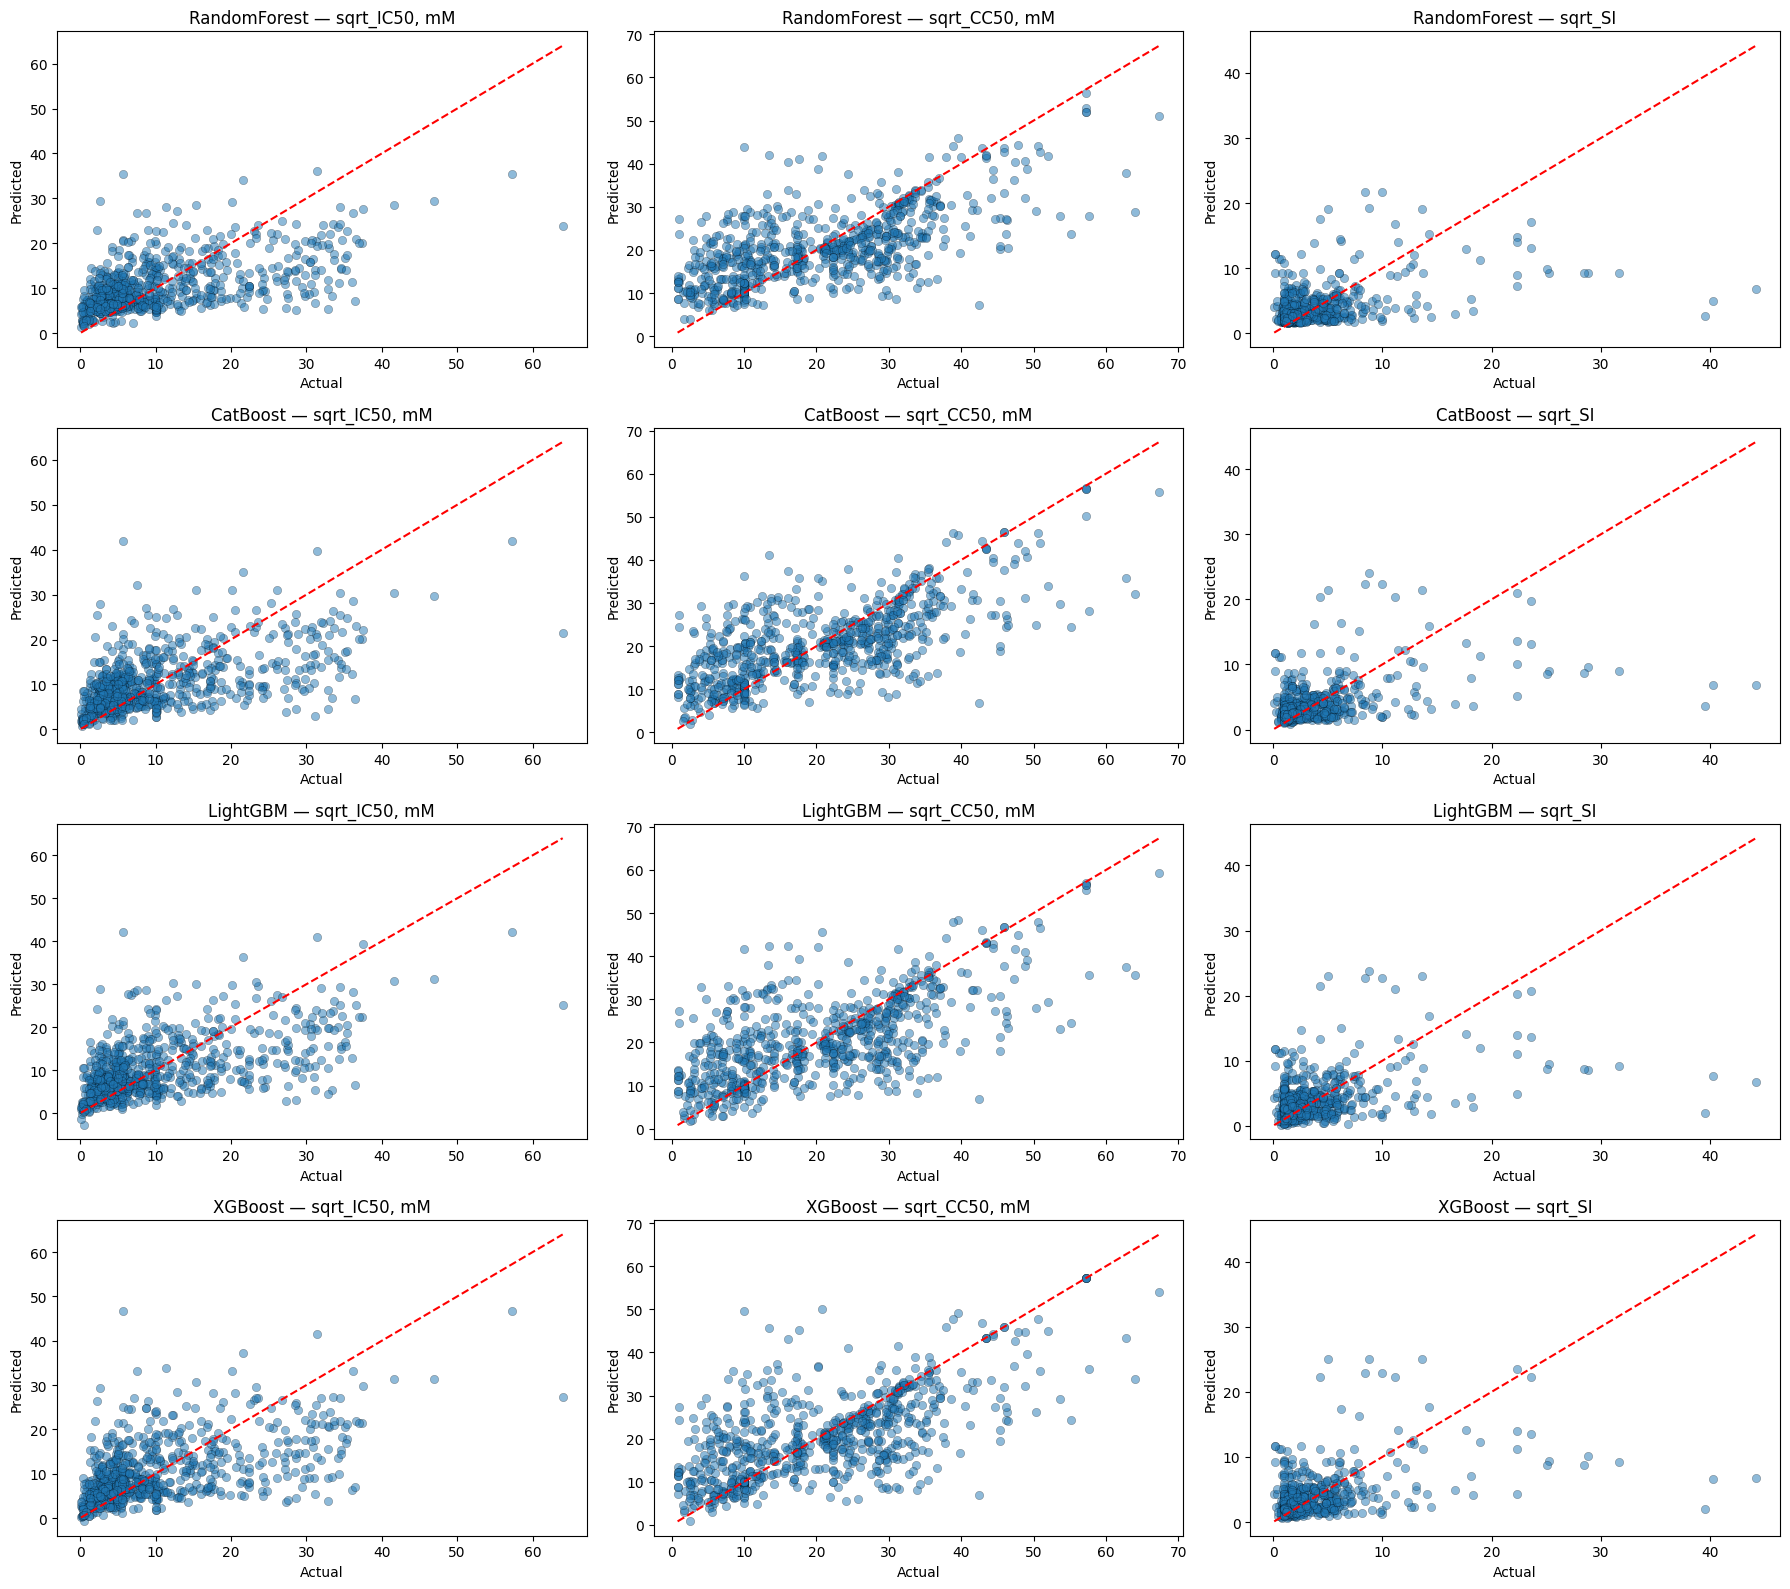

In [ ]:
fig, axes = plt.subplots(len(models_config), 3, figsize=(18, 4 * len(models_config)))

for row, (name, res) in enumerate(results.items()):
    preds_oof = res['preds_oof']
    for col, target_name in enumerate(TARGETS):
        axes[row, col].scatter(y[:, col], preds_oof[:, col], alpha=0.5, edgecolors='k', linewidth=0.3)
        axes[row, col].plot([y[:, col].min(), y[:, col].max()],
                            [y[:, col].min(), y[:, col].max()], 'r--')
        axes[row, col].set_xlabel('Actual')
        axes[row, col].set_ylabel('Predicted')
        axes[row, col].set_title(f'{name} — {target_name}')

plt.tight_layout()
plt.show()

Все модели демонстрируют умеренную предсказательную способность: наблюдается положительная линейная зависимость между фактическими и предсказанными значениями, особенно в области низких и средних значений. Однако качество предсказаний заметно падает на высоких значениях — модели систематически недооценивают большие значения sqrt_IC50 и sqrt_CC50, а точки сильно рассеиваются вокруг диагонали.  

Наибольший разброс и отклонения от идеальной линии видны на таргете sqrt_SI, где модели плохо справляются с предсказанием высоких значений. Лучше всего модели работают в диапазоне низких значений (до 15–20), где плотность точек максимальна и отклонения минимальны.  

Среди моделей XGBoost и CatBoost показывают чуть более плотное расположение точек вокруг диагонали и меньше систематических ошибок, в то время как RandomForest и LightGBM демонстрируют больший разброс.

## Residuals для всех моделей

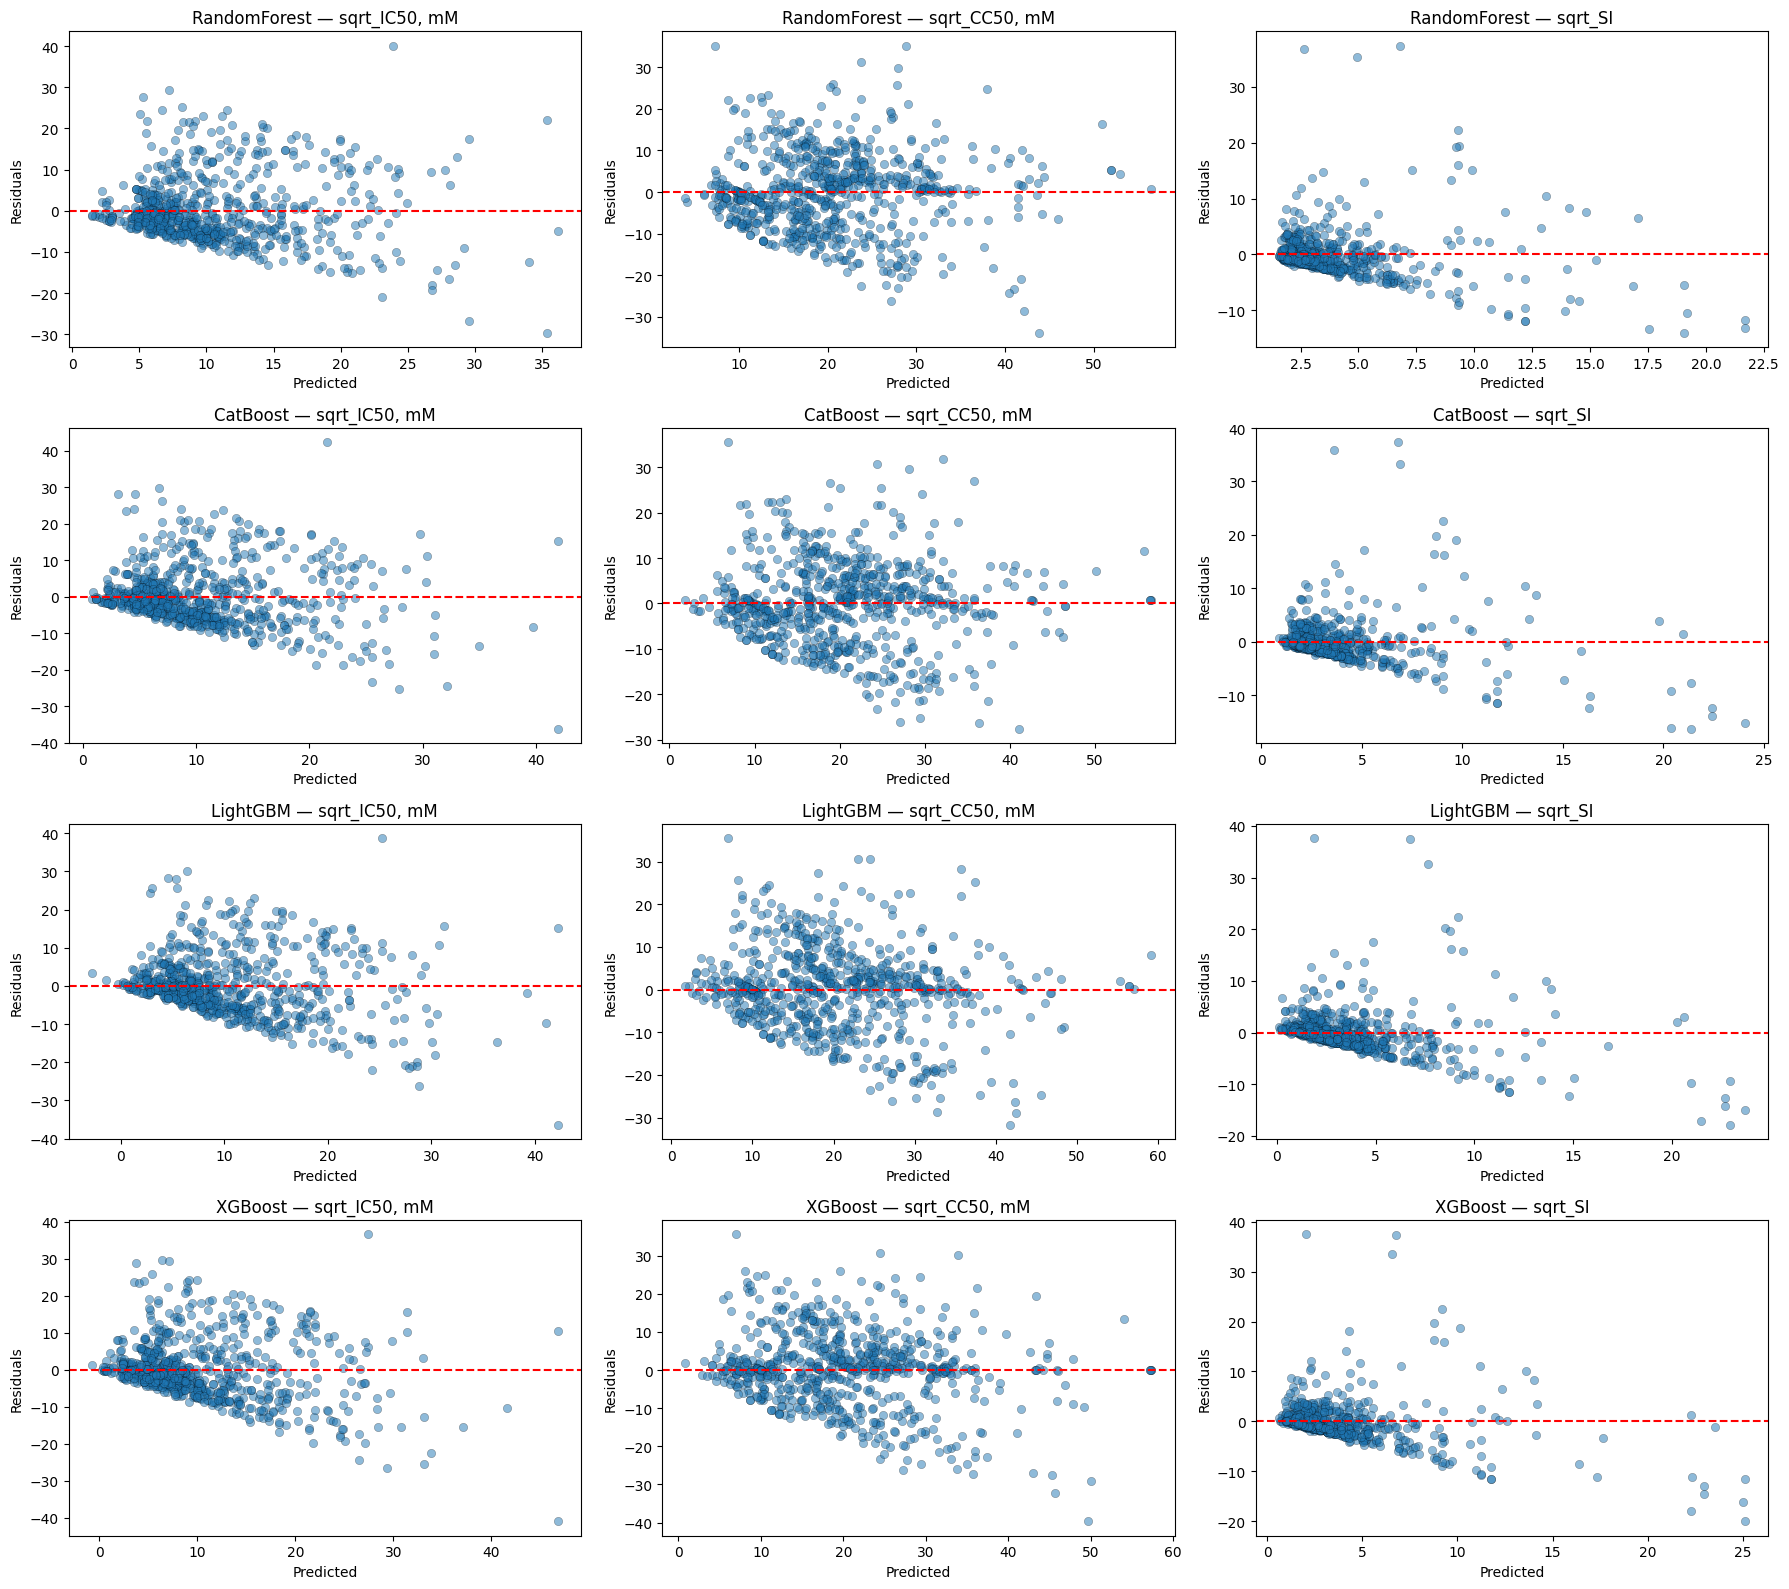

In [ ]:
fig, axes = plt.subplots(len(models_config), 3, figsize=(18, 4 * len(models_config)))

for row, (name, res) in enumerate(results.items()):
    preds_oof = res['preds_oof']
    for col, target_name in enumerate(TARGETS):
        residuals = y[:, col] - preds_oof[:, col]
        axes[row, col].scatter(preds_oof[:, col], residuals, alpha=0.5, edgecolors='k', linewidth=0.3)
        axes[row, col].axhline(y=0, color='r', linestyle='--')
        axes[row, col].set_xlabel('Predicted')
        axes[row, col].set_ylabel('Residuals')
        axes[row, col].set_title(f'{name} — {target_name}')

plt.tight_layout()
plt.show()

Все четыре модели (RandomForest, CatBoost, LightGBM и XGBoost) в целом демонстрируют хорошее качество предсказаний. Среднее значение остатков близко к нулю по всем целевым переменным, что говорит об отсутствии систематического смещения. Основная масса предсказаний лежит в достаточно компактном диапазоне остатков, особенно для умеренных значений целевых переменных.  

Однако практически во всех графиках явно выражена гетероскедастичность: разброс остатков заметно увеличивается по мере роста предсказанных значений. Это особенно заметно на sqrt_IC50 и sqrt_CC50, где при высоких предсказанных значениях (выше 20–25) появляется значительный разброс и большое количество выбросов. Также наблюдаются отдельные экстремальные остатки до ±30–40, что указывает на наличие труднопредсказуемых объектов или возможных выбросов в данных.  

Среди моделей наиболее сбалансированные результаты показывает XGBoost — у него меньше экстремальных выбросов и более равномерное распределение остатков по всем трём таргетам. CatBoost также выглядит очень достойно, особенно на IC50, а RandomForest и LightGBM демонстрируют чуть больший шум и разброс на высоких значениях.

## Кривые обучения для всех моделей

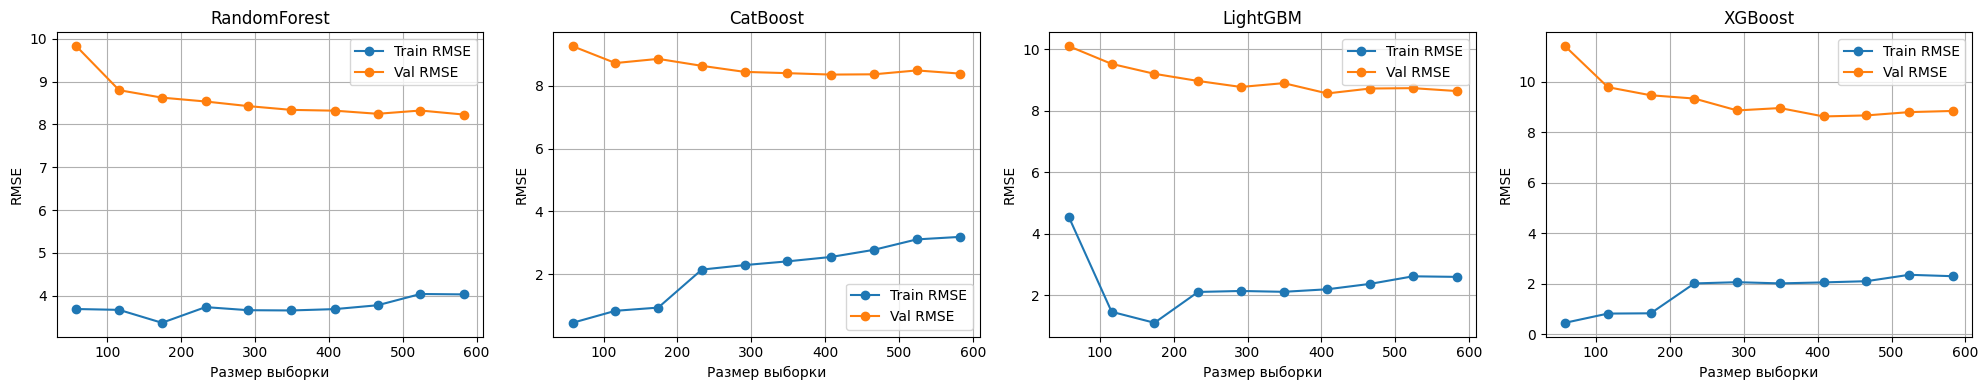

In [ ]:
fig, axes = plt.subplots(1, len(models_config), figsize=(5 * len(models_config), 4))

for idx, (name, (model_class, params)) in enumerate(models_config.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model_class(**params, random_state=SEED),
        X, y[:, 0],
        cv=5,
        scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    ax = axes[idx] if len(models_config) > 1 else axes
    ax.plot(train_sizes, -train_scores.mean(axis=1), 'o-', label='Train RMSE')
    ax.plot(train_sizes, -val_scores.mean(axis=1), 'o-', label='Val RMSE')
    ax.set_xlabel('Размер выборки')
    ax.set_ylabel('RMSE')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

Все модели показывают снижение Val RMSE при увеличении объёма данных, однако после 300–400 образцов улучшение практически останавливается. Это говорит о том, что текущего датасета уже почти достаточно.
Явно присутствует переобучение у всех моделей: Train RMSE значительно ниже Val RMSE (разрыв 5–6 единиц), особенно у CatBoost, LightGBM и XGBoost. RandomForest более стабилен, но показывает худшее качество на валидации.
XGBoost и CatBoost демонстрируют лучшие результаты на валидационной выборке

## SHAP для всех boosts


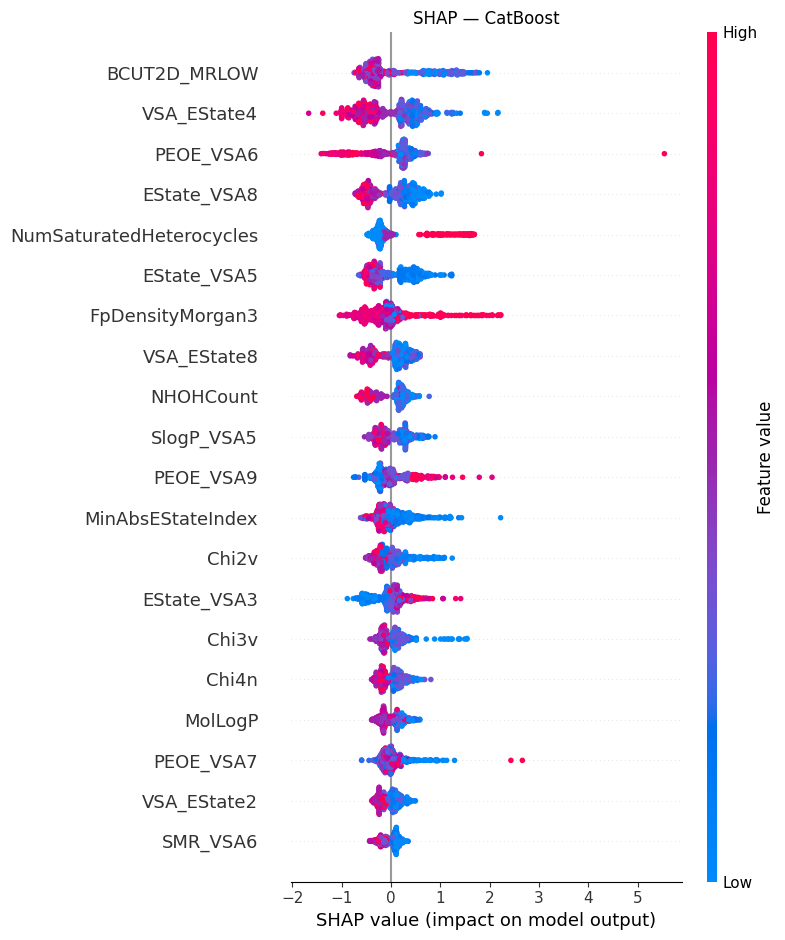

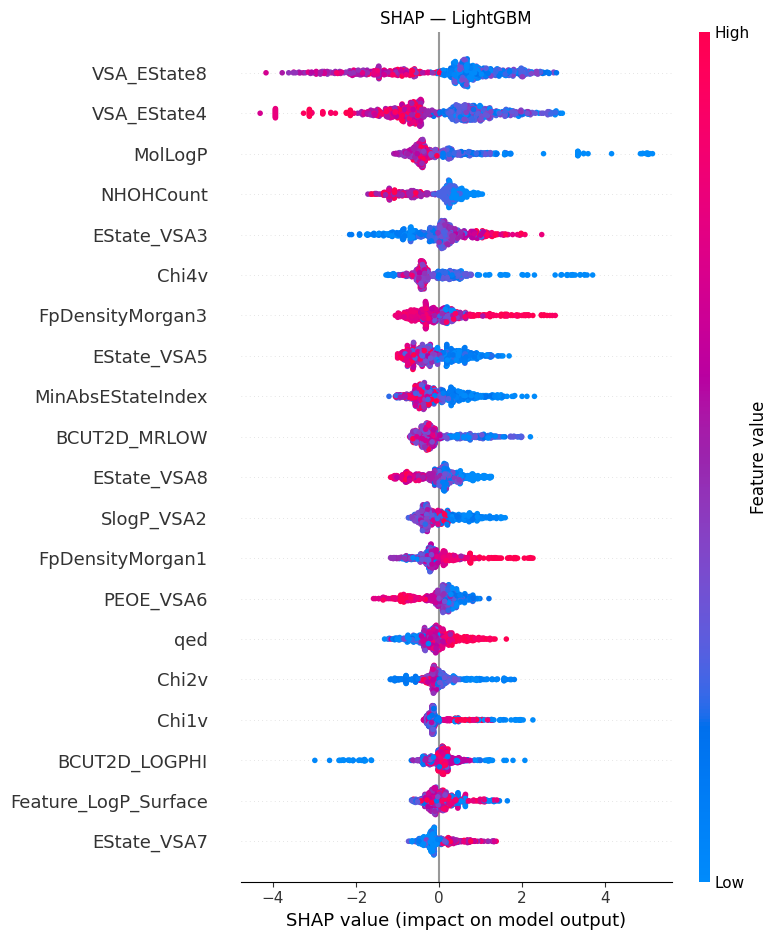

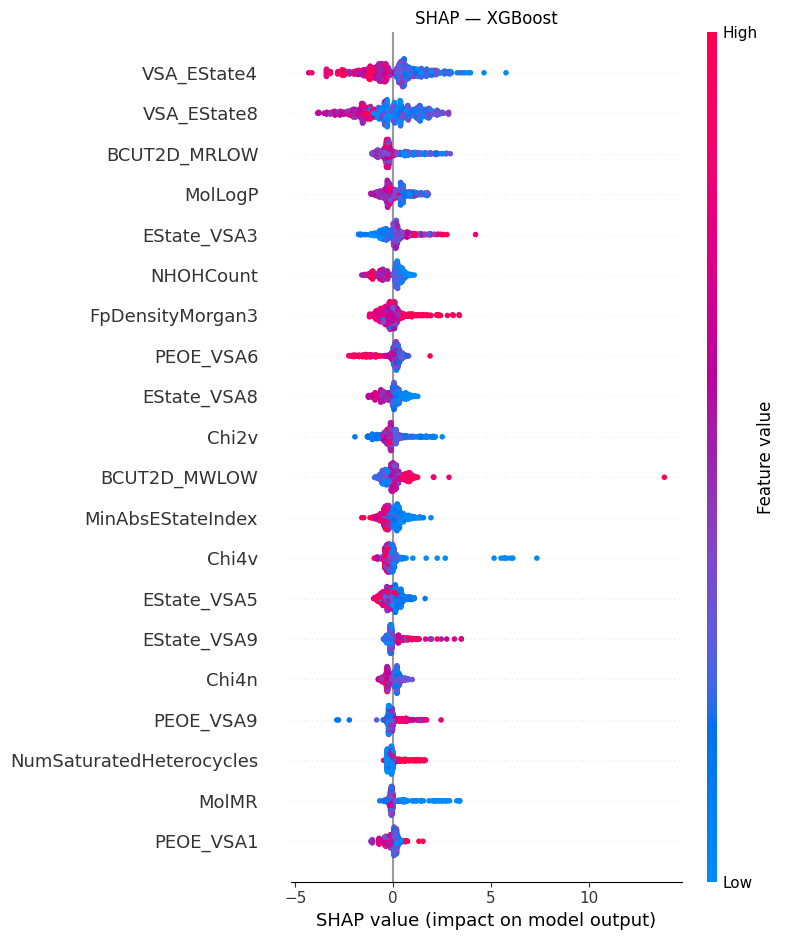

In [ ]:
for name in ['CatBoost', 'LightGBM', 'XGBoost']:
    model_class, params = models_config[name]
    model_shap = model_class(**params, random_state=SEED)
    model_shap.fit(X, y[:, 0])

    explainer = shap.TreeExplainer(model_shap)
    shap_values = explainer.shap_values(X)

    shap.summary_plot(shap_values, X, feature_names=feature_cols, show=False)
    plt.title(f'SHAP — {name}')
    plt.tight_layout()
    plt.show()

SHAP-диаграммы показывают, что все три модели (CatBoost, LightGBM и XGBoost) в значительной степени опираются на схожие группы дескрипторов. Наиболее важными признаками во всех моделях являются VSA_EState4, VSA_EState8, BCUT2D_MRLOW, MolLogP, NHOHCount и FpDensityMorgan3. Эти фичи имеют наибольший разброс влияния и часто сильно сдвигают предсказание модели как в положительную, так и в отрицательную сторону.  

Модели активно используют электронные и топологические дескрипторы (EState, PEOE_VSA, Chi-индексы), отражающие распределение зарядов, гидрофобность и форму молекулы. Признаки, связанные с липофильностью (MolLogP) и количеством определённых атомов (NHOHCount), стабильно входят в топ важности.

## Submissions для всех моделей

In [ ]:
'''
for name, res in results.items():
    preds_test_sqrt = res['preds_test']

    # Обратное преобразование: sqrt -> исходные единицы
    preds_test_orig = preds_test_sqrt ** 2

    submission = pd.DataFrame({
        'index': np.arange(len(preds_test_orig)),
        'IC50': preds_test_orig[:, 0],
        'CC50': preds_test_orig[:, 1],
        'SI': preds_test_orig[:, 2]
    })
    filename = f'submission_{name.lower()}_dataEF_3targ.csv'
    submission.to_csv(filename, index=False)
    print(f"Сохранён: {filename}")
'''

'\nfor name, res in results.items():\n    preds_test_sqrt = res[\'preds_test\']\n\n    # Обратное преобразование: sqrt -> исходные единицы\n    preds_test_orig = preds_test_sqrt ** 2\n\n    submission = pd.DataFrame({\n        \'index\': np.arange(len(preds_test_orig)),\n        \'IC50\': preds_test_orig[:, 0],\n        \'CC50\': preds_test_orig[:, 1],\n        \'SI\': preds_test_orig[:, 2]\n    })\n    filename = f\'submission_{name.lower()}.csv\'\n    submission.to_csv(filename, index=False)\n    print(f"Сохранён: {filename}")\n'

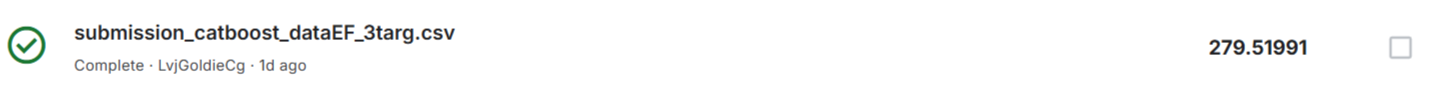

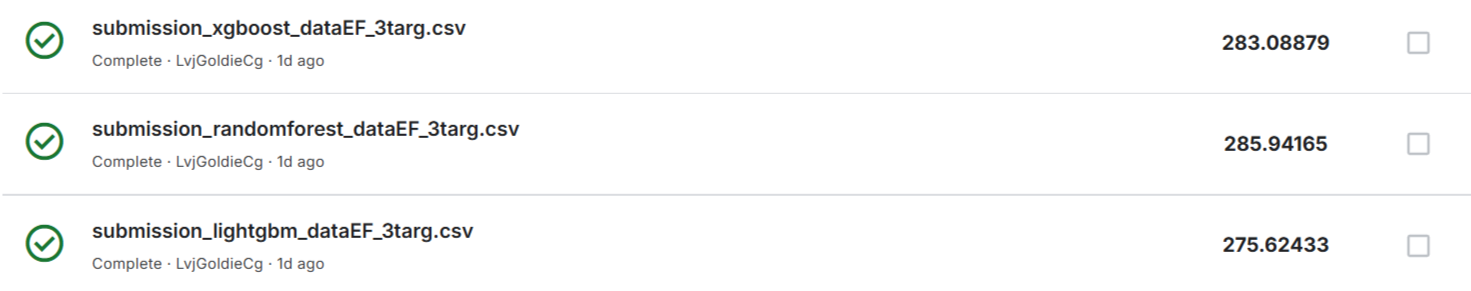

Поскольку CatBoost и LightGBM продемонстрировали лучшие результаты на Kaggle среди всех рассмотренных моделей, дальнейшее улучшение качества будет достигнуто путём тщательной оптимизации гиперпараметров этих двух алгоритмов с помощью Optuna.
Это позволит более точно настроить ключевые параметры, снизить переобучение и повысить обобщающую способность моделей на тестовых данных.

## Optuna — общая функция (использует custom_rmse)

In [ ]:
def objective(trial, model_name, target_idx):
    if model_name == 'CatBoost':
        params = {
            'iterations': 500,
            'depth': trial.suggest_int('depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'random_seed': SEED, 'verbose': 0,
        }
        model = CatBoostRegressor(**params)
    else:
        params = {
            'n_estimators': 500,
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
            'random_state': SEED, 'verbose': -1,
        }
        model = LGBMRegressor(**params)

    scores = []
    kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
    for train_idx, val_idx in kf.split(X):
        model.fit(X[train_idx], y[train_idx, target_idx])
        pred = model.predict(X[val_idx])

        preds_oof = np.zeros((len(val_idx), 3))
        preds_oof[:, target_idx] = pred
        y_true = np.zeros((len(val_idx), 3))
        y_true[:, target_idx] = y_orig[val_idx, target_idx]
        y_pred = np.zeros((len(val_idx), 3))
        y_pred[:, target_idx] = np.clip(pred, 0, None)**2

        scores.append(custom_rmse(
            y_true[:, 0], y_true[:, 1], y_true[:, 2],
            y_pred[:, 0], y_pred[:, 1], y_pred[:, 2]
        ))
    return np.mean(scores)

## Запуск Optuna для CatBoost и LightGBM

In [ ]:
optuna_results = {}

for model_name in ['CatBoost', 'LightGBM']:
    optuna_results[model_name] = {}
    for target_idx in range(3):
        study = optuna.create_study(direction='minimize')
        study.optimize(lambda trial: objective(trial, model_name, target_idx), n_trials=30)
        optuna_results[model_name][target_idx] = study
        print(f"{model_name} {TARGETS_ORIG[target_idx]}: RMSE={study.best_value:.2f}")

[I 2026-05-29 16:10:11,599] A new study created in memory with name: no-name-4f853a71-863e-4d98-a504-c4bfedda561c
[I 2026-05-29 16:10:33,126] Trial 0 finished with value: 109.4222688436866 and parameters: {'depth': 5, 'learning_rate': 0.030169215030206097, 'l2_leaf_reg': 6, 'subsample': 0.9895346267101242}. Best is trial 0 with value: 109.4222688436866.
[I 2026-05-29 16:10:42,617] Trial 1 finished with value: 108.88831367480509 and parameters: {'depth': 3, 'learning_rate': 0.09465545258469717, 'l2_leaf_reg': 2, 'subsample': 0.6247864987698902}. Best is trial 1 with value: 108.88831367480509.
[I 2026-05-29 16:11:04,458] Trial 2 finished with value: 111.03864478194008 and parameters: {'depth': 5, 'learning_rate': 0.025441743804411034, 'l2_leaf_reg': 8, 'subsample': 0.93517246553158}. Best is trial 1 with value: 108.88831367480509.
[I 2026-05-29 16:11:40,872] Trial 3 finished with value: 109.08641365821863 and parameters: {'depth': 6, 'learning_rate': 0.06534122661406076, 'l2_leaf_reg': 9

CatBoost IC50, mM: RMSE=108.52


[I 2026-05-29 16:27:47,550] Trial 0 finished with value: 159.66513821415842 and parameters: {'depth': 8, 'learning_rate': 0.07804753620740087, 'l2_leaf_reg': 5, 'subsample': 0.9601775598439009}. Best is trial 0 with value: 159.66513821415842.
[I 2026-05-29 16:27:57,018] Trial 1 finished with value: 158.2531270980751 and parameters: {'depth': 3, 'learning_rate': 0.06775814577545355, 'l2_leaf_reg': 3, 'subsample': 0.9352428746729231}. Best is trial 1 with value: 158.2531270980751.
[I 2026-05-29 16:28:19,855] Trial 2 finished with value: 155.97715899016714 and parameters: {'depth': 5, 'learning_rate': 0.036748612866286674, 'l2_leaf_reg': 4, 'subsample': 0.9558717030397605}. Best is trial 2 with value: 155.97715899016714.
[I 2026-05-29 16:28:42,171] Trial 3 finished with value: 156.94648319133674 and parameters: {'depth': 5, 'learning_rate': 0.028439031201054087, 'l2_leaf_reg': 9, 'subsample': 0.8464658345548909}. Best is trial 2 with value: 155.97715899016714.
[I 2026-05-29 16:28:56,467] 

CatBoost CC50, mM: RMSE=155.72


[I 2026-05-29 16:40:44,345] Trial 0 finished with value: 41.43019942205467 and parameters: {'depth': 3, 'learning_rate': 0.03826650756471152, 'l2_leaf_reg': 9, 'subsample': 0.685451449606112}. Best is trial 0 with value: 41.43019942205467.
[I 2026-05-29 16:41:07,339] Trial 1 finished with value: 41.620669112345496 and parameters: {'depth': 5, 'learning_rate': 0.022406040398389317, 'l2_leaf_reg': 2, 'subsample': 0.7701255793804586}. Best is trial 0 with value: 41.43019942205467.
[I 2026-05-29 16:41:45,642] Trial 2 finished with value: 42.29675029995397 and parameters: {'depth': 6, 'learning_rate': 0.060936823127157376, 'l2_leaf_reg': 6, 'subsample': 0.9943100417551544}. Best is trial 0 with value: 41.43019942205467.
[I 2026-05-29 16:41:53,737] Trial 3 finished with value: 41.27403735456094 and parameters: {'depth': 3, 'learning_rate': 0.01980426940458445, 'l2_leaf_reg': 7, 'subsample': 0.9449701388508718}. Best is trial 3 with value: 41.27403735456094.
[I 2026-05-29 16:43:52,917] Trial 

...

LightGBM IC50, mM: RMSE=108.33


[I 2026-05-29 16:58:56,642] Trial 0 finished with value: 164.4756818278469 and parameters: {'max_depth': 8, 'learning_rate': 0.023779828389541555, 'subsample': 0.7541991249008642, 'reg_lambda': 4.941004621564402}. Best is trial 0 with value: 164.4756818278469.
[I 2026-05-29 16:58:59,001] Trial 1 finished with value: 162.61070623311468 and parameters: {'max_depth': 5, 'learning_rate': 0.014736645322138501, 'subsample': 0.7598194420259043, 'reg_lambda': 8.33721417421675}. Best is trial 1 with value: 162.61070623311468.
[I 2026-05-29 16:59:00,852] Trial 2 finished with value: 160.66247625735784 and parameters: {'max_depth': 4, 'learning_rate': 0.012649836897354924, 'subsample': 0.9885425313462617, 'reg_lambda': 0.18012937646289337}. Best is trial 2 with value: 160.66247625735784.
[I 2026-05-29 16:59:03,450] Trial 3 finished with value: 160.75556938467568 and parameters: {'max_depth': 5, 'learning_rate': 0.03853864310756492, 'subsample': 0.6223157739726676, 'reg_lambda': 0.4096890990269027

LightGBM CC50, mM: RMSE=159.06


[I 2026-05-29 17:00:00,632] Trial 0 finished with value: 41.90676336908004 and parameters: {'max_depth': 8, 'learning_rate': 0.030881849167708517, 'subsample': 0.9349569305502156, 'reg_lambda': 5.793373435366729}. Best is trial 0 with value: 41.90676336908004.
[I 2026-05-29 17:00:03,998] Trial 1 finished with value: 42.81733746099551 and parameters: {'max_depth': 8, 'learning_rate': 0.049392282606396436, 'subsample': 0.733432101078728, 'reg_lambda': 0.880835755270134}. Best is trial 0 with value: 41.90676336908004.
[I 2026-05-29 17:00:06,483] Trial 2 finished with value: 42.83601018522896 and parameters: {'max_depth': 5, 'learning_rate': 0.06165888045790607, 'subsample': 0.6282503508896676, 'reg_lambda': 6.2776353779823}. Best is trial 0 with value: 41.90676336908004.
[I 2026-05-29 17:00:08,633] Trial 3 finished with value: 42.89383955572388 and parameters: {'max_depth': 4, 'learning_rate': 0.08828886490895671, 'subsample': 0.8896679218523287, 'reg_lambda': 0.40694684273959714}. Best i

LightGBM SI: RMSE=41.00


## Лучшие параметры Optuna

In [ ]:
for model_name in ['CatBoost', 'LightGBM']:
    print(f"\n{model_name}:")
    for target_idx in range(3):
        study = optuna_results[model_name][target_idx]
        print(f"  {TARGETS_ORIG[target_idx]}: {study.best_params}")


CatBoost:
  IC50, mM: {'depth': 4, 'learning_rate': 0.051200406249135216, 'l2_leaf_reg': 3, 'subsample': 0.8479223573611853}
  CC50, mM: {'depth': 4, 'learning_rate': 0.02709033347899698, 'l2_leaf_reg': 2, 'subsample': 0.8946092984343744}
  SI: {'depth': 6, 'learning_rate': 0.015058234739816826, 'l2_leaf_reg': 10, 'subsample': 0.963670948210024}

LightGBM:
  IC50, mM: {'max_depth': 5, 'learning_rate': 0.049350422347124515, 'subsample': 0.9523377918494289, 'reg_lambda': 4.313927387679875}
  CC50, mM: {'max_depth': 3, 'learning_rate': 0.023176943276082444, 'subsample': 0.9926830389253073, 'reg_lambda': 0.10049784816555586}
  SI: {'max_depth': 5, 'learning_rate': 0.012503895426662819, 'subsample': 0.655209376243457, 'reg_lambda': 0.31942571412253445}


Подобранные параметры отличаются для каждого таргета, что позволяет учитывать индивидуальные особенности распределений IC50, CC50 и SI. Эти настройки должны обеспечить лучшее обобщение моделей по сравнению с базовыми версиями.

## Submissions для CatBoost и LightGBM

In [ ]:
for model_name in ['CatBoost', 'LightGBM']:
    study_dict = optuna_results[model_name]
    preds_test_optuna = np.zeros((len(X_test), 3))

    for target_idx in range(3):
        best_params = study_dict[target_idx].best_params
        if model_name == 'CatBoost':
            model = CatBoostRegressor(
                iterations=500, depth=best_params['depth'],
                learning_rate=best_params['learning_rate'],
                l2_leaf_reg=best_params['l2_leaf_reg'],
                subsample=best_params['subsample'],
                random_seed=SEED, verbose=0
            )
        else:
            model = LGBMRegressor(
                n_estimators=500, max_depth=best_params['max_depth'],
                learning_rate=best_params['learning_rate'],
                subsample=best_params['subsample'],
                reg_lambda=best_params['reg_lambda'],
                random_state=SEED, verbose=-1
            )
        model.fit(X, y[:, target_idx])
        preds_test_optuna[:, target_idx] = model.predict(X_test)

    preds_test_orig = preds_test_optuna ** 2
    submission = pd.DataFrame({
        'index': np.arange(len(preds_test_orig)),
        'IC50': preds_test_orig[:, 0],
        'CC50': preds_test_orig[:, 1],
        'SI': preds_test_orig[:, 2]
    })
    submission.to_csv(f'submission_{model_name.lower()}_dataEF_3targ_OPTUNA.csv', index=False)
    print(f"Сохранён: submission_{model_name.lower()}_dataEF_3targ_OPTUNA.csv")

Сохранён: submission_catboost_dataEF_3targ_OPTUNA.csv
Сохранён: submission_lightgbm_dataEF_3targ_OPTUNA.csv


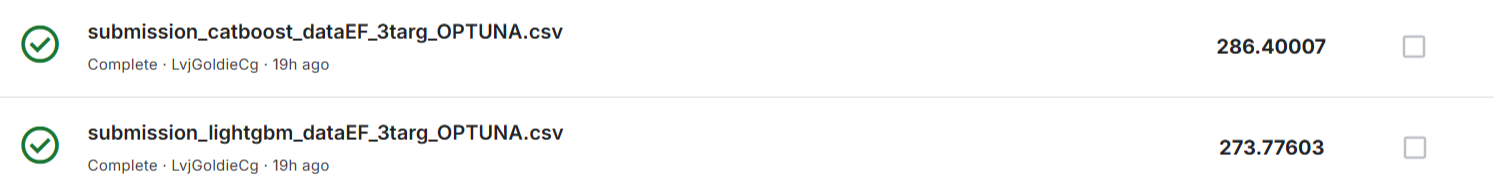

После применения подобранных через Optuna гиперпараметров результаты моделей разделились. LightGBM показал ожидаемое улучшение качества по сравнению с базовой версией, что подтверждает успешность оптимизации для данного алгоритма. Параметры хорошо подошли к особенностям данных.

В то же время CatBoost продемонстрировал ухудшение результата. Это довольно распространённая ситуация при автоматическом тюнинге и может быть связано с тем, что подобранные параметры (особенно низкие значения depth и learning_rate) привели к недообучению или неоптимальному балансу регуляризации на данном датасете.